In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

df = pd.read_parquet(Path("./data/processed/combat_rolls.parquet"))

# Explode dice into individual face values
att_faces = df["attacker_dice"].explode().dropna().astype(int)
def_faces = df["defender_dice"].explode().dropna().astype(int)


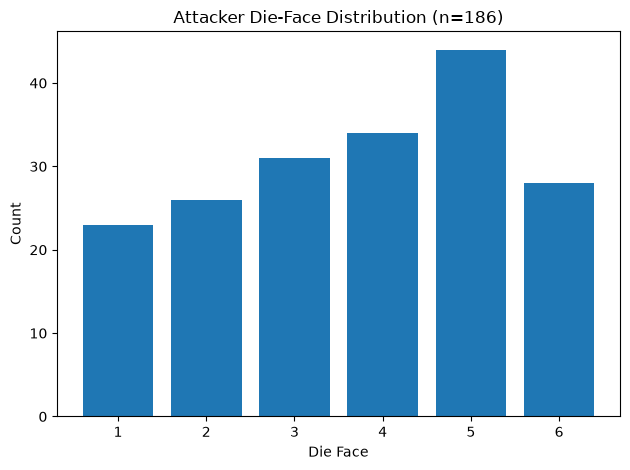

In [15]:
# Attacker die distribution
counts = att_faces.value_counts().reindex(range(1,7), fill_value=0).sort_index()
plt.bar(counts.index, counts.values)
plt.title(f"Attacker Die-Face Distribution (n={len(att_faces):,})")
plt.xlabel("Die Face"); plt.ylabel("Count"); plt.xticks(range(1,7))
plt.tight_layout(); plt.show()

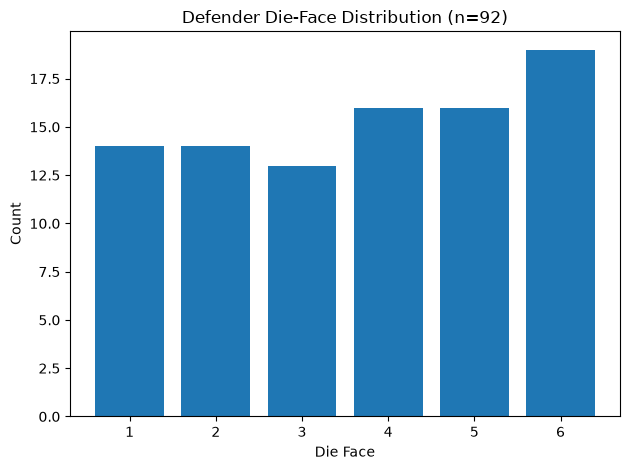

In [16]:
# Defender die distribution
counts = def_faces.value_counts().reindex(range(1,7), fill_value=0).sort_index()
plt.bar(counts.index, counts.values)
plt.title(f"Defender Die-Face Distribution (n={len(def_faces):,})")
plt.xlabel("Die Face"); plt.ylabel("Count"); plt.xticks(range(1,7))
plt.tight_layout(); plt.show()

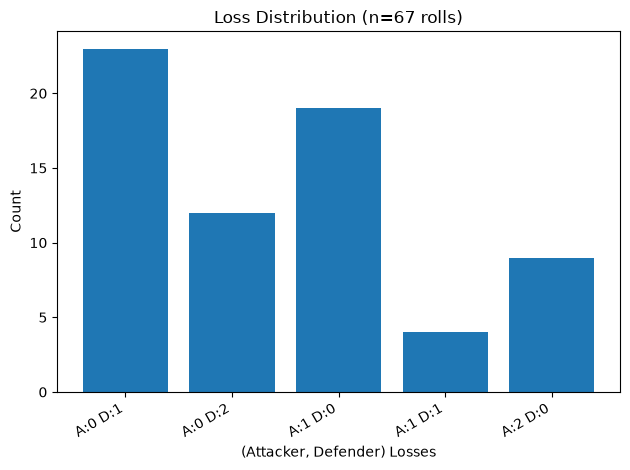

In [17]:
# Loss distribution
loss_counts = df.groupby(["attacker_losses","defender_losses"]).size()
labels = [f"A:{a} D:{d}" for a,d in loss_counts.index]
plt.bar(range(len(labels)), loss_counts.values)
plt.xticks(range(len(labels)), labels, rotation=30, ha="right")
plt.title(f"Loss Distribution (n={len(df):,} rolls)")
plt.xlabel("(Attacker, Defender) Losses"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

In [19]:
import pandas as pd
df = pd.read_csv("./reports/generated/combat/validation_failures.csv")
print(df["field"].value_counts())
print(df.head(20))

field
attacker_dice    67
defender_dice    67
Name: count, dtype: int64
    row_index                              event_id  \
0           0  22ce771b-4e16-4e21-b645-0b7f6c5f6c06   
1           0  22ce771b-4e16-4e21-b645-0b7f6c5f6c06   
2           1  0c2cd90d-87d9-40f6-a527-576f35e8db00   
3           1  0c2cd90d-87d9-40f6-a527-576f35e8db00   
4           2  f93bb2a0-37f7-4084-b102-9e0e4f356aba   
5           2  f93bb2a0-37f7-4084-b102-9e0e4f356aba   
6           3  c518e440-9302-4802-be82-d9dbdbdb8042   
7           3  c518e440-9302-4802-be82-d9dbdbdb8042   
8           4  6ffeb98c-3bbf-460b-b9bf-99bcd23f9078   
9           4  6ffeb98c-3bbf-460b-b9bf-99bcd23f9078   
10          5  c38a4c14-250a-468d-aa93-44133a069e53   
11          5  c38a4c14-250a-468d-aa93-44133a069e53   
12          6  1115412c-0585-4c17-9e61-c273c88ec121   
13          6  1115412c-0585-4c17-9e61-c273c88ec121   
14          7  4cbff99d-e7f7-4295-9093-cd8185acb270   
15          7  4cbff99d-e7f7-4295-9093-cd8185acb